In [1]:
# This notebook demonstrated:

# * Advanced Spark SQL analytics
# * Window functions
# * CTEs
# * Aggregations
# * Ranking functions
# * Multi-table joins
# * IPL performance insights
# * Visual analytics using Matplotlib


# SQL + Analytics

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

import pandas as pd
import matplotlib.pyplot as plt

In [3]:

try:
    spark.stop()
except:
    pass
from pyspark.sql import SparkSession 

spark = (
    SparkSession.builder
    .appName("S3App")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/26 07:42:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/26 07:42:17 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/06/26 07:42:17 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/06/26 07:42:17 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/06/26 07:42:17 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


# PATHs FOR Load Gold Layer Parquet Files

In [5]:

# ==============================
# 0.0 GOLD LAYER PARQUET PATHS
# ==============================

GOLD_PATH = "/opt/spark-data/4_gold"

batting_summary_path = f"{GOLD_PATH}/batting_summary"
bowling_summary_path = f"{GOLD_PATH}/bowling_summary"
death_over_analysis_path = f"{GOLD_PATH}/death_over_analysis"
orange_cap_path = f"{GOLD_PATH}/orange_cap"
venue_analysis_path = f"{GOLD_PATH}/venue_analysis"
team_performance_path = f"{GOLD_PATH}/team_performance"
match_fact_table_path = f"{GOLD_PATH}/match_fact_table"

# ==============================
# 0.1 READ GOLD DATA
# ==============================

batting_df = spark.read.parquet(
    batting_summary_path
)

bowling_df = spark.read.parquet(
    bowling_summary_path
)

death_df = spark.read.parquet(
    death_over_analysis_path
)

orange_df = spark.read.parquet(
    orange_cap_path
)

venue_df = spark.read.parquet(
    venue_analysis_path
)

team_df = spark.read.parquet(
    team_performance_path
)

match_df = spark.read.parquet(
    match_fact_table_path
)

# Create Temporary SQL Views

In [6]:
batting_df.createOrReplaceTempView("batting_summary")
bowling_df.createOrReplaceTempView("bowling_summary")
death_df.createOrReplaceTempView("death_over_analysis")
orange_df.createOrReplaceTempView("orange_cap")
venue_df.createOrReplaceTempView("venue_analysis")
team_df.createOrReplaceTempView("team_performance")
match_df.createOrReplaceTempView("match_fact_table")

In [7]:
batting_df.select("striker","striker_name").show()

+-------+--------------+
|striker|  striker_name|
+-------+--------------+
|    395| Anureet Singh|
|    141|   Younis Khan|
|    427|       Hm Amla|
|    307|    Mn Samuels|
|    403|Mj Mcclenaghan|
|     26| Kc Sangakkara|
|     17|      Pa Patel|
|    325|A Ashish Reddy|
|    256| Harmeet Singh|
|    212|       P Dogra|
|    266|    Al Menaria|
|    157|      Jd Ryder|
|    330|   Ap Majumdar|
|    396| Ks Williamson|
|    107|    Sp Fleming|
|    259|      Rv Gomez|
|    343|    B Laughlin|
|    429|       Bb Sran|
|    178|      Tl Suman|
|    172|   Aa Bilakhia|
+-------+--------------+
only showing top 20 rows



In [8]:
batting_df.columns 

['striker',
 'striker_name',
 'total_runs',
 'balls_faced',
 'fours',
 'sixes',
 'matches',
 'strike_rate']

# Analysis 1 - Top 10 Run Scorers with Strike Rate

### Concepts Used
- Aggregation
- HAVING
- ORDER BY

In [9]:
query1 = """

SELECT
striker,striker_name,
SUM(total_runs) AS total_runs,
ROUND(SUM(total_runs) * 100.0 / SUM(balls_faced), 2) AS strike_rate

FROM batting_summary

GROUP BY striker,striker_name

ORDER BY total_runs DESC

LIMIT 10

"""

spark.sql(query1).show(truncate=False)

+-------+--------------+----------+-----------+
|striker|striker_name  |total_runs|strike_rate|
+-------+--------------+----------+-----------+
|21     |Sk Raina      |4548      |135.00     |
|8      |V Kohli       |4413      |126.30     |
|57     |Rg Sharma     |4207      |128.50     |
|40     |G Gambhir     |4132      |120.36     |
|187    |Da Warner     |4014      |138.32     |
|46     |Rv Uthappa    |3778      |127.64     |
|162    |Ch Gayle      |3647      |144.09     |
|42     |S Dhawan      |3561      |118.50     |
|20     |Ms Dhoni      |3560      |132.84     |
|110    |Ab De Villiers|3486      |145.13     |
+-------+--------------+----------+-----------+



# Runs scored greater than 4000

In [10]:
# Runs scored greater than 4000

query1 = """

SELECT
striker,striker_name,
SUM(total_runs) AS total_runs,
ROUND(SUM(total_runs) * 100.0 / SUM(balls_faced), 2) AS strike_rate

FROM batting_summary

GROUP BY striker,striker_name

HAVING total_runs>4000

ORDER BY total_runs DESC

"""

spark.sql(query1).show(truncate=False)

+-------+------------+----------+-----------+
|striker|striker_name|total_runs|strike_rate|
+-------+------------+----------+-----------+
|21     |Sk Raina    |4548      |135.00     |
|8      |V Kohli     |4413      |126.30     |
|57     |Rg Sharma   |4207      |128.50     |
|40     |G Gambhir   |4132      |120.36     |
|187    |Da Warner   |4014      |138.32     |
+-------+------------+----------+-----------+



# Analysis 2 - Best Bowling Economy Rate

## Concepts

- Aggregate Functions
- Filtering
- ROUND

In [11]:
# 3rd-silver-39,4rth-gold-21 correction

In [12]:
bowling_df.columns


['bowler',
 'bowler_name',
 'runs_conceded',
 'balls_bowled',
 'wickets',
 'overs',
 'economy']

In [13]:
query2 = """

SELECT
    bowler,
    bowler_name,

    SUM(wickets) AS total_wickets,

    ROUND(
        SUM(runs_conceded) / SUM(overs),
        2
    ) AS economy

FROM bowling_summary

GROUP BY
    bowler,
    bowler_name

HAVING SUM(wickets) > 100

ORDER BY economy ASC

LIMIT 10

"""

spark.sql(query2).show(truncate=False)

+------+---------------+-------------+-------+
|bowler|bowler_name    |total_wickets|economy|
+------+---------------+-------------+-------+
|315   |Sp Narine      |109          |6.4    |
|201   |R Ashwin       |110          |6.49   |
|194   |Sl Malinga     |170          |6.75   |
|50    |Harbhajan Singh|136          |6.93   |
|299   |B Kumar        |117          |7.02   |
|136   |A Mishra       |142          |7.32   |
|15    |Z Khan         |119          |7.54   |
|14    |P Kumar        |102          |7.61   |
|67    |Pp Chawla      |133          |7.67   |
|73    |A Nehra        |121          |7.71   |
+------+---------------+-------------+-------+



# Analysis 3 - Orange Cap Winners Ranking using Window Functions

- DENSE_RANK
- Window Functions

In [14]:
orange_df.columns

['season_year', 'striker', 'striker_name', 'season_runs', 'rank']

In [15]:
query3 = """

WITH ranked_players AS (

    SELECT
        striker,
        striker_name,
        season_year,
        season_runs,

        DENSE_RANK() OVER(
            PARTITION BY season_year
            ORDER BY season_runs DESC
        ) AS rank

    FROM orange_cap

)

SELECT *

FROM ranked_players

WHERE rank <= 3

ORDER BY season_year, rank

"""

spark.sql(query3).show(truncate=False)

+-------+------------+-----------+-----------+----+
|striker|striker_name|season_year|season_runs|rank|
+-------+------------+-----------+-----------+----+
|100    |Se Marsh    |2008       |616        |1   |
|18     |Ml Hayden   |2009       |572        |1   |
|133    |Sr Tendulkar|2010       |617        |1   |
|162    |Ch Gayle    |2011       |604        |1   |
|162    |Ch Gayle    |2012       |733        |1   |
|19     |Mek Hussey  |2013       |733        |1   |
|46     |Rv Uthappa  |2014       |660        |1   |
|187    |Da Warner   |2015       |562        |1   |
|8      |V Kohli     |2016       |969        |1   |
|187    |Da Warner   |2017       |641        |1   |
+-------+------------+-----------+-----------+----+



# Analysis 4 - Most Successful Teams by Win Percentage

## Concepts

- CASE WHEN
- Percentage Calculations

In [16]:
team_df .columns

['match_winner',
 'wins',
 'total_team_runs',
 'total_wickets_lost',
 'balls_played',
 'total_fours',
 'total_sixes',
 'team_strike_rate',
 'run_rate',
 'boundary_percentage']

In [17]:
query4 = """

SELECT
    match_winner,

    wins,

    total_team_runs,

    ROUND(run_rate, 2) AS run_rate,

    ROUND(boundary_percentage, 2) AS boundary_percentage

FROM team_performance

ORDER BY wins DESC

LIMIT 10

"""

spark.sql(query4).show(truncate=False)

+---------------------------+----+---------------+--------+-------------------+
|match_winner               |wins|total_team_runs|run_rate|boundary_percentage|
+---------------------------+----+---------------+--------+-------------------+
|Mumbai Indians             |91  |28205          |7.73    |55.41              |
|Chennai Super Kings        |79  |24696          |7.8     |54.5               |
|Kolkata Knight Riders      |77  |22551          |7.49    |53.34              |
|Royal Challengers Bangalore|73  |22498          |7.96    |57.53              |
|Kings Xi Punjab            |70  |22001          |7.96    |56.35              |
|Rajasthan Royals           |63  |19239          |7.64    |54.71              |
|Delhi Daredevils           |62  |19141          |7.9     |55.99              |
|Sunrisers Hyderabad        |42  |12671          |7.63    |53.14              |
|Deccan Chargers            |29  |8739           |7.48    |54.13              |
|Rising Pune Supergiants    |15  |4300  

# Analysis 5 - Best Death Over Bowlers

## Concepts

- CTE
- Aggregations
- Advanced Sorting

In [18]:
death_df.columns

['team_batting',
 'death_runs',
 'balls',
 'fours',
 'sixes',
 'wickets_lost',
 'death_strike_rate',
 'run_rate']

In [19]:
query5 = """

SELECT
    team_batting,

    death_runs,

    wickets_lost,

    ROUND(run_rate, 2) AS run_rate,

    ROUND(death_strike_rate, 2) AS death_strike_rate

FROM death_over_analysis

WHERE balls > 120

ORDER BY death_runs DESC

LIMIT 10

"""

spark.sql(query5).show(truncate=False)

+------------+----------+------------+--------+-----------------+
|team_batting|death_runs|wickets_lost|run_rate|death_strike_rate|
+------------+----------+------------+--------+-----------------+
|7           |6328      |331         |9.67    |161.22           |
|2           |6028      |276         |10.23   |170.48           |
|3           |5946      |261         |9.69    |161.49           |
|4           |5491      |306         |9.04    |150.69           |
|1           |5196      |269         |9.27    |154.5            |
|6           |5017      |262         |9.05    |150.75           |
|5           |4500      |246         |8.9     |148.27           |
|8           |3133      |198         |8.94    |148.98           |
|11          |2620      |145         |9.14    |152.33           |
|10          |1733      |115         |8.11    |135.18           |
+------------+----------+------------+--------+-----------------+



# Analysis 6 - Venue Wise Average First Innings Score

## Concepts

- GROUP BY
- AVG

In [20]:
venue_df.columns

['venue_name',
 'avg_runs_per_ball',
 'total_runs_scored',
 'total_wickets',
 'total_fours',
 'total_sixes',
 'matches',
 'avg_runs_per_match',
 'boundary_percentage']

In [21]:
query6 = """

SELECT
    venue_name,

    matches,

    total_runs_scored,

    ROUND(avg_runs_per_match, 2) AS avg_runs_per_match,

    ROUND(boundary_percentage, 2) AS boundary_percentage

FROM venue_analysis

ORDER BY avg_runs_per_match DESC

LIMIT 10

"""

spark.sql(query6).show(truncate=False)

+----------------------------------------------------+-------+-----------------+------------------+-------------------+
|venue_name                                          |matches|total_runs_scored|avg_runs_per_match|boundary_percentage|
+----------------------------------------------------+-------+-----------------+------------------+-------------------+
|Brabourne Stadium                                   |11     |3841             |349.18            |55.4               |
|Saurashtra Cricket Association Stadium              |10     |3333             |333.3             |55.45              |
|Punjab Cricket Association IS Bindra Stadium, Mohali|7      |2321             |331.57            |51.62              |
|Barabati Stadium                                    |7      |2278             |325.43            |55.66              |
|Green Park                                          |4      |1298             |324.5             |63.17              |
|Himachal Pradesh Cricket Association St

# Analysis 7 - Players Consistent Across Seasons

## Concepts

- COUNT DISTINCT
- Aggregations

In [22]:
orange_df.columns

['season_year', 'striker', 'striker_name', 'season_runs', 'rank']

In [23]:
query7 = """

SELECT
    striker,
    striker_name,

    COUNT(DISTINCT season_year) AS seasons_played,

    SUM(season_runs) AS career_runs,

    ROUND(
        AVG(season_runs),
        2
    ) AS avg_runs_per_season

FROM orange_cap

GROUP BY
    striker,
    striker_name

HAVING COUNT(DISTINCT season_year) >= 2

ORDER BY career_runs DESC

LIMIT 10

"""

spark.sql(query7).show(truncate=False)

+-------+------------+--------------+-----------+-------------------+
|striker|striker_name|seasons_played|career_runs|avg_runs_per_season|
+-------+------------+--------------+-----------+-------------------+
|162    |Ch Gayle    |2             |1337       |668.5              |
|187    |Da Warner   |2             |1203       |601.5              |
+-------+------------+--------------+-----------+-------------------+



# Analysis 8 - Maximum matches BY venue_name

## Concepts

- CASE WHEN
- Categorization
- Aggregation

In [24]:
 match_df.columns

['match_id',
 'season_year',
 'venue_name',
 'team_batting',
 'team_bowling',
 'total_runs',
 'extras',
 'balls',
 'wickets']

In [25]:
query8 = """

SELECT

    venue_name,

    COUNT(match_id) AS total_matches,

    SUM(total_runs) AS total_runs_scored,

    ROUND(
        AVG(total_runs),
        2
    ) AS avg_runs_per_match,

    SUM(wickets) AS total_wickets

FROM match_fact_table

GROUP BY venue_name

ORDER BY total_matches DESC

LIMIT 10

"""

spark.sql(query8).show(truncate=False)

+------------------------------------------+-------------+-----------------+------------------+-------------+
|venue_name                                |total_matches|total_runs_scored|avg_runs_per_match|total_wickets|
+------------------------------------------+-------------+-----------------+------------------+-------------+
|M Chinnaswamy Stadium                     |131          |19423            |148.27            |760          |
|Eden Gardens                              |122          |17105            |140.2             |690          |
|Feroz Shah Kotla                          |119          |17491            |146.98            |697          |
|Wankhede Stadium                          |114          |16996            |149.09            |699          |
|MA Chidambaram Stadium, Chepauk           |96           |14471            |150.74            |566          |
|Rajiv Gandhi International Stadium, Uppal |82           |11748            |143.27            |467          |
|Punjab Cr

# Analysis 9 - Top All Rounders

## Concepts

- Multi-table Join
- CTE
- Ranking

In [26]:
print(batting_df.columns)
print(bowling_df.columns)

['striker', 'striker_name', 'total_runs', 'balls_faced', 'fours', 'sixes', 'matches', 'strike_rate']
['bowler', 'bowler_name', 'runs_conceded', 'balls_bowled', 'wickets', 'overs', 'economy']


In [27]:
# Balling allrounders wickets > 100 and runs> 1000

In [28]:

# balling allrounders
query = """

WITH batting AS (
    SELECT
        striker AS player_id,
        striker_name,
        SUM(total_runs) AS total_runs
    FROM batting_summary
    GROUP BY striker, striker_name
    HAVING SUM(total_runs) > 1000
),

bowling AS (
    SELECT
        bowler AS player_id,
        bowler_name,
        SUM(wickets) AS total_wickets
    FROM bowling_summary
    GROUP BY bowler, bowler_name
    HAVING SUM(wickets) > 100
)

SELECT
    b.player_id,
    b.striker_name AS player_name,
    b.total_runs,
    bw.total_wickets

FROM batting b

INNER JOIN bowling bw
ON b.player_id = bw.player_id

ORDER BY total_runs DESC, total_wickets DESC

"""

spark.sql(query).show(truncate=False)

+---------+-----------+----------+-------------+
|player_id|player_name|total_runs|total_wickets|
+---------+-----------+----------+-------------+
|71       |Dj Bravo   |1262      |137          |
+---------+-----------+----------+-------------+



# Batter allrounders wickets > 50,  and runs> 2000

In [29]:

# Batter allrounders
query = """

WITH batting AS (
    SELECT
        striker AS player_id,
        striker_name,
        SUM(total_runs) AS total_runs
    FROM batting_summary
    GROUP BY striker, striker_name
    HAVING SUM(total_runs) > 2000
),

bowling AS (
    SELECT
        bowler AS player_id,
        bowler_name,
        SUM(wickets) AS total_wickets
    FROM bowling_summary
    GROUP BY bowler, bowler_name
    HAVING SUM(wickets) > 50
)

SELECT
    b.player_id,
    b.striker_name AS player_name,
    b.total_runs,
    bw.total_wickets

FROM batting b

INNER JOIN bowling bw
ON b.player_id = bw.player_id

ORDER BY total_runs DESC, total_wickets DESC

"""

spark.sql(query).show(truncate=False)

+---------+-----------+----------+-------------+
|player_id|player_name|total_runs|total_wickets|
+---------+-----------+----------+-------------+
|32       |Sr Watson  |2624      |100          |
|9        |Jh Kallis  |2427      |74           |
|221      |Ka Pollard |2354      |67           |
+---------+-----------+----------+-------------+



# Analysis 10 - Most Winning TOP  Teams

## Concepts

- Window Functions
- PARTITION BY
- DENSE_RANK

In [30]:
query = """

SELECT
    match_winner,
    wins,
    total_team_runs,
    run_rate,
    boundary_percentage

FROM team_performance

WHERE match_winner IS NOT NULL
AND match_winner != 'Null'

ORDER BY wins DESC

LIMIT 5

"""

spark.sql(query).show(truncate=False)

+---------------------------+----+---------------+--------+-------------------+
|match_winner               |wins|total_team_runs|run_rate|boundary_percentage|
+---------------------------+----+---------------+--------+-------------------+
|Mumbai Indians             |91  |28205          |7.73    |55.41              |
|Chennai Super Kings        |79  |24696          |7.8     |54.5               |
|Kolkata Knight Riders      |77  |22551          |7.49    |53.34              |
|Royal Challengers Bangalore|73  |22498          |7.96    |57.53              |
|Kings Xi Punjab            |70  |22001          |7.96    |56.35              |
+---------------------------+----+---------------+--------+-------------------+



In [31]:
team_df.columns

['match_winner',
 'wins',
 'total_team_runs',
 'total_wickets_lost',
 'balls_played',
 'total_fours',
 'total_sixes',
 'team_strike_rate',
 'run_rate',
 'boundary_percentage']

In [32]:
query = "select* from team_performance"


spark.sql(query).show(truncate=False)

+---------------------------+----+---------------+------------------+------------+-----------+-----------+----------------+--------+-------------------+
|match_winner               |wins|total_team_runs|total_wickets_lost|balls_played|total_fours|total_sixes|team_strike_rate|run_rate|boundary_percentage|
+---------------------------+----+---------------+------------------+------------+-----------+-----------+----------------+--------+-------------------+
|Sunrisers Hyderabad        |42  |12671          |505               |9964        |1091       |395        |127.17          |7.63    |53.14              |
|Chennai Super Kings        |79  |24696          |925               |18994       |2075       |860        |130.02          |7.8     |54.5               |
|Deccan Chargers            |29  |8739           |369               |7013        |710        |315        |124.61          |7.48    |54.13              |
|Kochi Tuskers Kerala       |6   |1661           |60                |1322        |

In [33]:
# batting_df.createOrReplaceTempView("batting_summary")
# bowling_df.createOrReplaceTempView("bowling_summary")
# death_df.createOrReplaceTempView("death_over_analysis")
# orange_df.createOrReplaceTempView("orange_cap")
# venue_df.createOrReplaceTempView("venue_analysis")
# team_df.createOrReplaceTempView("team_performance")
# match_df.createOrReplaceTempView("match_fact_table")

# Visualization 1 - Top 10 Run Scorers

In [34]:
batting_df.columns

['striker',
 'striker_name',
 'total_runs',
 'balls_faced',
 'fours',
 'sixes',
 'matches',
 'strike_rate']

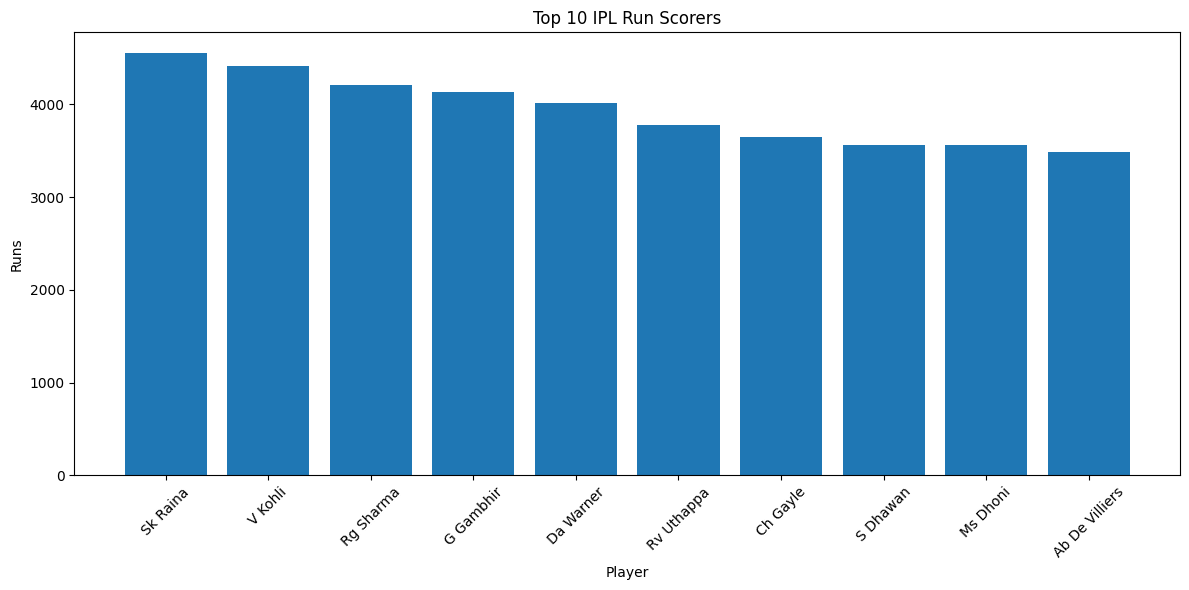

In [35]:
import matplotlib.pyplot as plt

viz1_query = """

SELECT
    striker,
    striker_name,
    SUM(total_runs) AS total_runs

FROM batting_summary

GROUP BY
    striker,
    striker_name

ORDER BY total_runs DESC

LIMIT 10

"""

viz1_df = spark.sql(viz1_query).toPandas()


plt.figure(figsize=(12,6))

plt.bar(
    viz1_df['striker_name'],
    viz1_df['total_runs']
)

plt.xticks(rotation=45)

plt.xlabel("Player")
plt.ylabel("Runs")

plt.title("Top 10 IPL Run Scorers")

plt.tight_layout()

plt.show()

# Visualization 2 - Top 10 Wicket Takers

In [36]:
bowling_df.columns

['bowler',
 'bowler_name',
 'runs_conceded',
 'balls_bowled',
 'wickets',
 'overs',
 'economy']

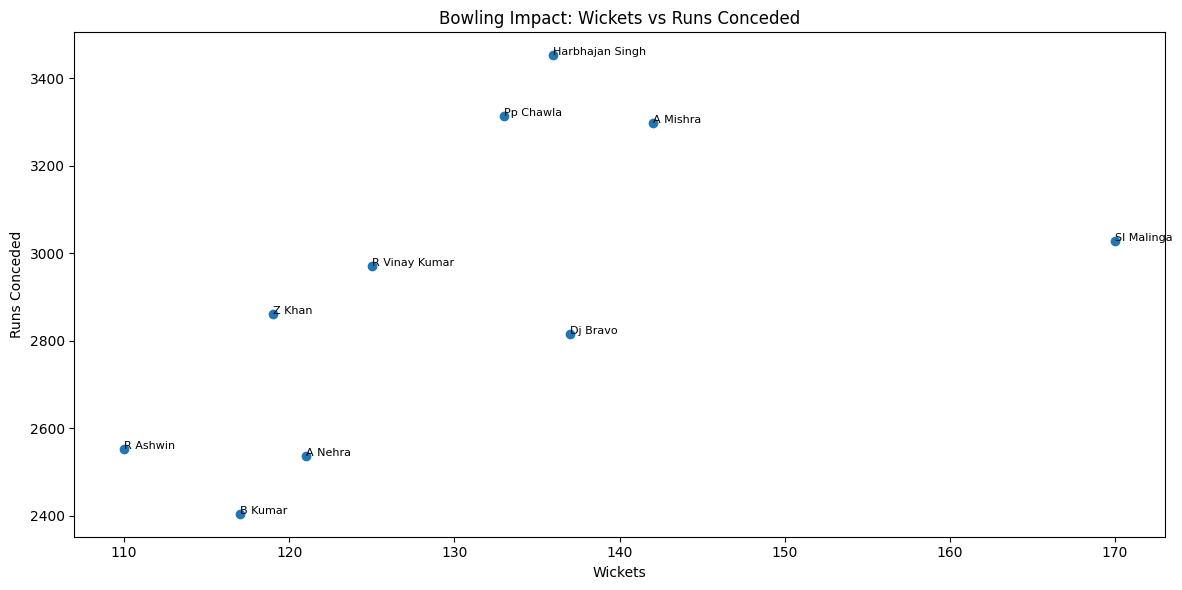

In [37]:
viz_query = """

SELECT
    bowler,
    bowler_name,
    SUM(wickets) AS wickets,
    SUM(runs_conceded) AS runs_conceded,
    SUM(overs) AS overs,
    ROUND(SUM(runs_conceded) / SUM(overs), 2) AS economy

FROM bowling_summary

GROUP BY bowler, bowler_name

ORDER BY wickets DESC

LIMIT 10

"""

viz_df = spark.sql(viz_query).toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.scatter(
    viz_df['wickets'],
    viz_df['runs_conceded']
)

for i in range(len(viz_df)):
    plt.text(
        viz_df['wickets'][i],
        viz_df['runs_conceded'][i],
        viz_df['bowler_name'][i],
        fontsize=8
    )

plt.xlabel("Wickets")
plt.ylabel("Runs Conceded")
plt.title("Bowling Impact: Wickets vs Runs Conceded")

plt.tight_layout()
plt.show()

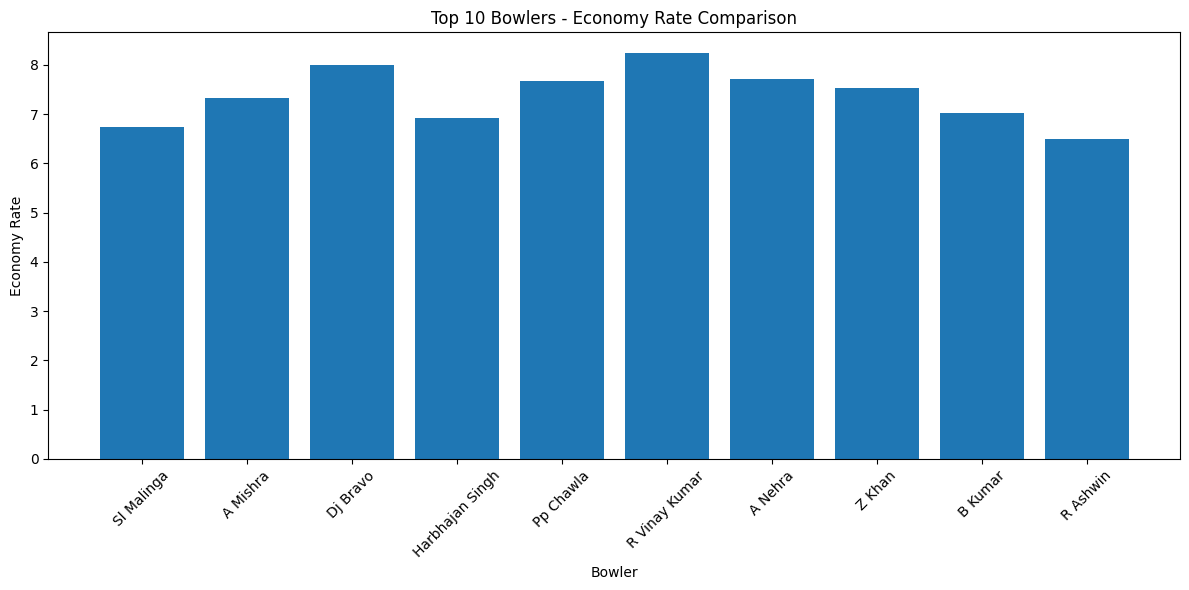

In [38]:
plt.figure(figsize=(12,6))

plt.bar(
    viz_df['bowler_name'],
    viz_df['economy']
)

plt.xticks(rotation=45)

plt.xlabel("Bowler")
plt.ylabel("Economy Rate")

plt.title("Top 10 Bowlers - Economy Rate Comparison")

plt.tight_layout()

plt.show()